# IPL Winner Prediction Using Historical Matches

This notebook builds a simple historical prediction model for IPL matches.

Model inputs (`X`):
- `team1`
- `team2`
- `venue`
- `toss_winner`
- `runs_scored`

Target (`y`):
- `winner`

Interpretation:
- `runs_scored` is the first-innings score.
- If `winner == team2`, then the chase was successful.
- If `winner == team1`, then team1 defended the total.

The notebook also checks whether some venues historically favored the home team.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

In [2]:
df = pd.read_csv('ipl.csv')
df.head()

,team1,team2,match_date,toss_winner,toss_decision,winner,player_of_match,venue,city,team1_players,team2_players,season,match_number,match_type,result,result_margin,target_runs,target_overs,super_over
0,Royal Challengers Bangalore,Kolkata Knight Riders,2008-04-18,Royal Challengers Bangalore,field,Kolkata Knight Riders,BB McCullum,M Chinnaswamy Stadium,Bangalore,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",1,1,League,runs,140.0,223.0,20.0,N
1,Kings XI Punjab,Chennai Super Kings,2008-04-19,Chennai Super Kings,bat,Chennai Super Kings,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Chandigarh,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",1,2,League,runs,33.0,241.0,20.0,N
2,Delhi Daredevils,Rajasthan Royals,2008-04-19,Rajasthan Royals,bat,Delhi Daredevils,MF Maharoof,Feroz Shah Kotla,Delhi,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm...",1,3,League,wickets,9.0,130.0,20.0,N
3,Mumbai Indians,Royal Challengers Bangalore,2008-04-20,Mumbai Indians,bat,Royal Challengers Bangalore,MV Boucher,Wankhede Stadium,Mumbai,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli...",1,4,League,wickets,5.0,166.0,20.0,N
4,Kolkata Knight Riders,Deccan Chargers,2008-04-20,Deccan Chargers,bat,Kolkata Knight Riders,DJ Hussey,Eden Gardens,Kolkata,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S...",1,5,League,wickets,5.0,111.0,20.0,N


In [3]:
team_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

valid_results = ['runs', 'wickets']

df = df.copy()
for col in ['team1', 'team2', 'winner', 'toss_winner']:
    df[col] = df[col].replace(team_map)

df = df[
    df['winner'].notna() &
    df['target_runs'].notna() &
    df['result'].isin(valid_results) &
    (df['super_over'] == 'N')
].copy()

# In a successful chase, target_runs = first innings runs + 1.
df['runs_scored'] = df['target_runs'] - 1
df['runs_scored'] = df['runs_scored'].astype(int)

df = df[['team1', 'team2', 'venue', 'toss_winner', 'runs_scored', 'winner']].copy()
df.head()

,team1,team2,venue,toss_winner,runs_scored,winner
0,Royal Challengers Bengaluru,Kolkata Knight Riders,M Chinnaswamy Stadium,Royal Challengers Bengaluru,222,Kolkata Knight Riders
1,Punjab Kings,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,240,Chennai Super Kings
2,Delhi Capitals,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,129,Delhi Capitals
3,Mumbai Indians,Royal Challengers Bengaluru,Wankhede Stadium,Mumbai Indians,165,Royal Challengers Bengaluru
4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,110,Kolkata Knight Riders


In [4]:
team_home_venues = {
    'Chennai Super Kings': ['MA Chidambaram Stadium, Chepauk', 'MA Chidambaram Stadium'],
    'Mumbai Indians': ['Wankhede Stadium', 'Dr DY Patil Sports Academy'],
    'Kolkata Knight Riders': ['Eden Gardens'],
    'Royal Challengers Bengaluru': ['M Chinnaswamy Stadium'],
    'Delhi Capitals': ['Arun Jaitley Stadium', 'Feroz Shah Kotla', 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium'],
    'Punjab Kings': ['Punjab Cricket Association Stadium, Mohali', 'Punjab Cricket Association IS Bindra Stadium, Mohali', 'Himachal Pradesh Cricket Association Stadium'],
    'Rajasthan Royals': ['Sawai Mansingh Stadium'],
    'Sunrisers Hyderabad': ['Rajiv Gandhi International Stadium, Uppal', 'Rajiv Gandhi International Stadium'],
    'Gujarat Titans': ['Narendra Modi Stadium', 'Sardar Patel Stadium, Motera'],
    'Lucknow Super Giants': ['Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium', 'Ekana Cricket Stadium']
}

def home_team_for_match(row):
    for team, venues in team_home_venues.items():
        if row['venue'] in venues and team in [row['team1'], row['team2']]:
            return team
    return 'Neutral'

venue_df = df.copy()
venue_df['home_team'] = venue_df.apply(home_team_for_match, axis=1)
venue_df = venue_df[venue_df['home_team'] != 'Neutral'].copy()
venue_df['home_team_won'] = (venue_df['winner'] == venue_df['home_team']).astype(int)

home_advantage_summary = (
    venue_df.groupby('home_team')
    .agg(
        home_matches=('home_team_won', 'size'),
        home_wins=('home_team_won', 'sum'),
        home_win_rate=('home_team_won', 'mean')
    )
    .sort_values(['home_win_rate', 'home_matches'], ascending=[False, False])
)

home_advantage_summary

,home_matches,home_wins,home_win_rate
home_team,,,
Chennai Super Kings,55,40,0.727273
Rajasthan Royals,47,32,0.680851
Sunrisers Hyderabad,43,29,0.674419
Mumbai Indians,73,46,0.630137
Kolkata Knight Riders,74,45,0.608108
Punjab Kings,55,27,0.490909
Royal Challengers Bengaluru,58,28,0.482759
Delhi Capitals,73,32,0.438356


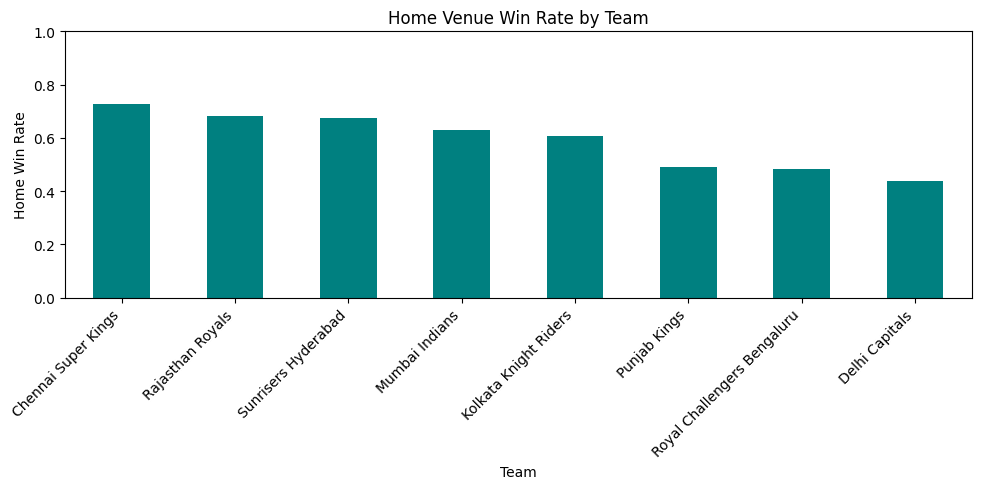

In [5]:
plt.figure(figsize=(10, 5))
home_advantage_summary['home_win_rate'].sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title('Home Venue Win Rate by Team')
plt.xlabel('Team')
plt.ylabel('Home Win Rate')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [6]:
X = df[['team1', 'team2', 'venue', 'toss_winner', 'runs_scored']]
y = df['winner']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((915, 5), (229, 5))

In [7]:
categorical_features = ['team1', 'team2', 'venue', 'toss_winner']
numeric_features = ['runs_scored']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=250, max_depth=10, min_samples_leaf=4, random_state=42)
}

In [8]:
results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    acc = accuracy_score(y_test, preds)

    results.append({'Model': name, 'Accuracy': acc})
    trained_models[name] = pipeline
    print(f'{name} Accuracy: {acc:.4f}')

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df

Decision Tree Accuracy: 0.4629
Random Forest Accuracy: 0.5328


,Model,Accuracy
1,Random Forest,0.532751
0,Decision Tree,0.462882


In [9]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

predictions = best_model.predict(X_test)

print('Best Model:', best_model_name)
print('Accuracy:', round(accuracy_score(y_test, predictions), 4))
print('\nConfusion Matrix:\n')
print(confusion_matrix(y_test, predictions))
print('\nClassification Report:\n')
print(classification_report(y_test, predictions, zero_division=0))

Best Model: Random Forest
Accuracy: 0.5328

Confusion Matrix:

[[18  0  0  0  0  0  3  0  2  0  1  4  0  0  1  0]
 [ 0  0  1  0  0  0  1  0  2  0  1  0  0  0  1  0]
 [ 4  0 12  0  0  0  1  1  2  0  0  3  0  0  1  0]
 [ 0  0  1  0  0  0  1  0  0  0  0  0  0  0  1  0]
 [ 0  0  1  0  3  0  1  0  0  0  0  1  0  0  0  1]
 [ 0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  2  0  0  0 19  0  1  0  0  1  0  0  4  0]
 [ 0  0  0  0  0  0  1  2  1  0  1  0  0  0  0  1]
 [ 1  0  1  0  0  0  3  0 23  0  1  1  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  1  0  0  0  0]
 [ 4  0  2  0  0  0  3  0  2  0  9  0  0  0  2  1]
 [ 2  0  2  0  0  0  0  0  3  0  0 14  0  0  0  2]
 [ 0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  1]
 [ 0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 3  0  2  0  0  0  0  0  3  0  2  2  0  0 13  1]
 [ 0  0  2  0  0  0  2  0  2  0  1  1  0  0  2  9]]

Classification Report:

                             precision    recall  f1-score   support

        Chennai Super Kin

In [10]:
new_match = pd.DataFrame({
    'team1': ['Mumbai Indians'],
    'team2': ['Chennai Super Kings'],
    'venue': ['Wankhede Stadium'],
    'toss_winner': ['Mumbai Indians'],
    'runs_scored': [185]
})

predicted_winner = best_model.predict(new_match)[0]
print('Predicted Winner:', predicted_winner)

if predicted_winner == new_match.loc[0, 'team2']:
    print('Interpretation: team2 is predicted to chase the target successfully.')
else:
    print('Interpretation: team1 is predicted to defend the score.')

Predicted Winner: Mumbai Indians
Interpretation: team1 is predicted to defend the score.
